# MovieLens EDA + pipeline + API

Ce notebook est proprement regenerable et executable de bout en bout sur Colab.
Il couvre:
- le setup Colab
- le choix d'un profil d'execution `fast`, `balanced` ou `full`
- une EDA rapide sur MovieLens
- l'execution complete du pipeline
- la verification des artefacts
- un test API directement dans le notebook
- un export zip pour recuperer facilement les resultats


## 0) Setup Colab

Cette cellule detecte Colab, clone le repo si besoin, installe Java 17 et les dependances Python.
En local, elle se replace a la racine du projet.


In [1]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/younesda/recommandation_film.git"

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "scripts").exists() and (candidate / "data").exists():
            return candidate
    return start

REPO_DIR = Path("/content/recommandation_film") if IN_COLAB else find_project_root(Path.cwd())

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    os.chdir(REPO_DIR)

    java_home = "/usr/lib/jvm/java-17-openjdk-amd64"
    java_bin = shutil.which("java")
    if (java_bin is None) or ("java-17" not in java_bin and "jdk-17" not in java_bin):
        subprocess.run(["apt-get", "update", "-y"], check=True)
        subprocess.run(["apt-get", "install", "-y", "openjdk-17-jdk-headless"], check=True)
    os.environ["JAVA_HOME"] = java_home
    os.environ["PATH"] = f"{java_home}/bin:" + os.environ["PATH"]

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    os.environ.setdefault("SPARK_DRIVER_MEMORY", "6g")
    os.environ.setdefault("SPARK_EXECUTOR_MEMORY", "6g")
else:
    os.chdir(REPO_DIR)
    os.environ.setdefault("SPARK_DRIVER_MEMORY", "4g")
    os.environ.setdefault("SPARK_EXECUTOR_MEMORY", "4g")

os.environ.setdefault("PYSPARK_PYTHON", sys.executable)
os.environ.setdefault("PYSPARK_DRIVER_PYTHON", sys.executable)
os.environ.setdefault("SPARK_LOCAL_IP", "127.0.0.1")
os.environ.setdefault("SPARK_LOCAL_HOSTNAME", "localhost")

print(f"IN_COLAB={IN_COLAB}")
print(f"REPO_DIR={REPO_DIR}")
print(f"PYTHON={sys.executable}")
print(f"JAVA_HOME={os.getenv('JAVA_HOME', 'not-set')}")
print(f"SPARK_DRIVER_MEMORY={os.environ['SPARK_DRIVER_MEMORY']}")
print(f"SPARK_EXECUTOR_MEMORY={os.environ['SPARK_EXECUTOR_MEMORY']}")


IN_COLAB=True
REPO_DIR=/content/recommandation_film
PYTHON=/usr/bin/python3
JAVA_HOME=/usr/lib/jvm/java-17-openjdk-amd64
SPARK_DRIVER_MEMORY=6g
SPARK_EXECUTOR_MEMORY=6g


## 1) Imports et config projet

On charge les modules du projet et quelques outils d'affichage pour piloter le run.


In [2]:
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from pyspark.sql import functions as F

from src.api.main import APP
from src.config.settings import ALSSettings, DataPaths, HybridSettings, PipelineSettings, RankerSettings
from src.ingestion.load_data import load_all_data
from src.pipelines.training_pipeline import run_pipeline
from src.preprocessing.clean_data import clean_movies, clean_ratings, clean_tags, time_based_split
from src.preprocessing.feature_engineering import add_time_features
from src.preprocessing.spark_session import create_spark
from src.utils.logging_utils import configure_logging

configure_logging("INFO")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

try:
    GIT_COMMIT = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip()
except Exception:
    GIT_COMMIT = "unknown"

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"GIT_COMMIT={GIT_COMMIT}")


PROJECT_ROOT=/content/recommandation_film
GIT_COMMIT=8f9b33e


## 2) Choix du profil d'execution

Utilise `fast` pour iterer vite, `balanced` pour Colab au quotidien, et `full` seulement si tu acceptes un run long.


In [3]:
RUN_PROFILE = "full"

PROFILE_CONFIGS = {
    "fast": {
        "description": "Iteration rapide pour valider l'environnement et obtenir un premier score ranking",
        "expected_runtime": "15-30 min",
        "candidate_multiplier": 15,
        "als_rank_candidates": [48],
        "als_reg_param_candidates": [0.08],
        "als_max_iter_candidates": [10],
        "ranking_rank_candidates": [64],
        "ranking_reg_param_candidates": [0.05],
        "ranking_alpha_candidates": [10.0],
        "ranking_max_iter_candidates": [10],
        "ranker_n_estimators_candidates": [120],
        "ranker_max_depth_candidates": [4],
        "ranker_learning_rate_candidates": [0.08],
        "ranker_min_child_weight_candidates": [1.0],
    },
    "balanced": {
        "description": "Meilleur compromis qualite / temps pour Colab",
        "expected_runtime": "35-70 min",
        "candidate_multiplier": 20,
        "als_rank_candidates": [48, 64],
        "als_reg_param_candidates": [0.05, 0.1],
        "als_max_iter_candidates": [10],
        "ranking_rank_candidates": [64],
        "ranking_reg_param_candidates": [0.03, 0.05],
        "ranking_alpha_candidates": [10.0, 20.0],
        "ranking_max_iter_candidates": [10],
        "ranker_n_estimators_candidates": [150],
        "ranker_max_depth_candidates": [4, 6],
        "ranker_learning_rate_candidates": [0.05],
        "ranker_min_child_weight_candidates": [1.0],
    },
    "full": {
        "description": "Recherche plus exhaustive, utile seulement pour un run final long",
        "expected_runtime": "90-150+ min",
        "candidate_multiplier": 40,
        "als_rank_candidates": [32, 48, 64, 96],
        "als_reg_param_candidates": [0.03, 0.05, 0.08, 0.1, 0.12],
        "als_max_iter_candidates": [10, 15],
        "ranking_rank_candidates": [64, 96],
        "ranking_reg_param_candidates": [0.01, 0.05, 0.1],
        "ranking_alpha_candidates": [5.0, 10.0, 20.0],
        "ranking_max_iter_candidates": [10, 15],
        "ranker_n_estimators_candidates": [150, 250],
        "ranker_max_depth_candidates": [4, 6],
        "ranker_learning_rate_candidates": [0.05, 0.1],
        "ranker_min_child_weight_candidates": [1.0, 5.0],
    },
}

if RUN_PROFILE not in PROFILE_CONFIGS:
    raise ValueError(f"Unknown RUN_PROFILE={RUN_PROFILE}. Expected one of {list(PROFILE_CONFIGS)}")

profile = PROFILE_CONFIGS[RUN_PROFILE]
profile_df = pd.DataFrame(
    [
        {"profile": name, **cfg}
        for name, cfg in PROFILE_CONFIGS.items()
    ]
)
display(profile_df[["profile", "description", "expected_runtime", "candidate_multiplier"]])
print(f"Selected profile: {RUN_PROFILE}")


,profile,description,expected_runtime,candidate_multiplier
0,fast,Iteration rapide pour valider l'environnement ...,15-30 min,15
1,balanced,Meilleur compromis qualite / temps pour Colab,35-70 min,20
2,full,"Recherche plus exhaustive, utile seulement pou...",90-150+ min,40


Selected profile: full


## 3) Parametres du run

Les hyperparametres sont derives du profil choisi ci-dessus. `full` est maintenant le defaut pour maximiser le score, au prix d'un run plus long.


In [4]:
TOP_K = 10
USE_TAGS = True
MIN_USER_INTERACTIONS = 20
MIN_ITEM_INTERACTIONS = 5
SHUFFLE_PARTITIONS = 16

settings = PipelineSettings(
    shuffle_partitions=SHUFFLE_PARTITIONS,
    min_user_interactions=MIN_USER_INTERACTIONS,
    min_item_interactions=MIN_ITEM_INTERACTIONS,
    data_paths=DataPaths(
        ratings=str(RAW_DIR / "ratings.csv"),
        movies=str(RAW_DIR / "movies.csv"),
        tags=str(RAW_DIR / "tags.csv"),
        output_base=str(PROCESSED_DIR),
    ),
    hybrid=HybridSettings(
        top_k=TOP_K,
        candidate_multiplier=profile["candidate_multiplier"],
        als_candidate_overfetch_multiplier=3,
    ),
    als=ALSSettings(
        rank_candidates=profile["als_rank_candidates"],
        reg_param_candidates=profile["als_reg_param_candidates"],
        max_iter_candidates=profile["als_max_iter_candidates"],
        ranking_rank_candidates=profile["ranking_rank_candidates"],
        ranking_reg_param_candidates=profile["ranking_reg_param_candidates"],
        ranking_alpha_candidates=profile["ranking_alpha_candidates"],
        ranking_max_iter_candidates=profile["ranking_max_iter_candidates"],
    ),
    ranker=RankerSettings(
        n_estimators_candidates=profile["ranker_n_estimators_candidates"],
        max_depth_candidates=profile["ranker_max_depth_candidates"],
        learning_rate_candidates=profile["ranker_learning_rate_candidates"],
        min_child_weight_candidates=profile["ranker_min_child_weight_candidates"],
    ),
)

params_df = pd.DataFrame(
    [
        {"parameter": "run_profile", "value": RUN_PROFILE},
        {"parameter": "expected_runtime", "value": profile["expected_runtime"]},
        {"parameter": "ratings_path", "value": settings.data_paths.ratings},
        {"parameter": "movies_path", "value": settings.data_paths.movies},
        {"parameter": "tags_path", "value": settings.data_paths.tags},
        {"parameter": "output_base", "value": settings.data_paths.output_base},
        {"parameter": "top_k", "value": settings.hybrid.top_k},
        {"parameter": "candidate_multiplier", "value": settings.hybrid.candidate_multiplier},
        {"parameter": "als_candidate_overfetch_multiplier", "value": settings.hybrid.als_candidate_overfetch_multiplier},
        {"parameter": "hybrid_weight_candidates", "value": settings.hybrid.hybrid_weight_candidates},
        {"parameter": "tag_weight_candidates", "value": settings.hybrid.tag_weight_candidates},
        {"parameter": "als_rank_candidates", "value": settings.als.rank_candidates},
        {"parameter": "als_reg_param_candidates", "value": settings.als.reg_param_candidates},
        {"parameter": "als_max_iter_candidates", "value": settings.als.max_iter_candidates},
        {"parameter": "ranking_rank_candidates", "value": settings.als.ranking_rank_candidates},
        {"parameter": "ranking_reg_param_candidates", "value": settings.als.ranking_reg_param_candidates},
        {"parameter": "ranking_alpha_candidates", "value": settings.als.ranking_alpha_candidates},
        {"parameter": "ranking_max_iter_candidates", "value": settings.als.ranking_max_iter_candidates},
        {"parameter": "ranker_n_estimators_candidates", "value": settings.ranker.n_estimators_candidates},
        {"parameter": "ranker_max_depth_candidates", "value": settings.ranker.max_depth_candidates},
        {"parameter": "ranker_learning_rate_candidates", "value": settings.ranker.learning_rate_candidates},
        {"parameter": "ranker_min_child_weight_candidates", "value": settings.ranker.min_child_weight_candidates},
    ]
)
display(params_df)


,parameter,value
0,run_profile,full
1,expected_runtime,90-150+ min
2,ratings_path,/content/recommandation_film/data/raw/ratings.csv
3,movies_path,/content/recommandation_film/data/raw/movies.csv
4,tags_path,/content/recommandation_film/data/raw/tags.csv
5,output_base,/content/recommandation_film/data/processed
6,top_k,10
7,candidate_multiplier,40
8,als_candidate_overfetch_multiplier,3
9,hybrid_weight_candidates,"[0.2, 0.35, 0.5, 0.65, 0.8, 0.9]"


## 4) Creation de la session Spark

Cette session est celle utilisee ensuite pour l'EDA et le pipeline.


In [5]:
spark = create_spark(settings=settings)
print(f"Spark version={spark.version}")
print(f"Spark app name={spark.sparkContext.appName}")


Spark version=4.0.2
Spark app name=MovieLensHybridRecommender


## 5) Chargement des donnees brutes

On charge les CSV MovieLens, avec mise en cache en parquet si besoin.


In [6]:
ratings_df, movies_df, tags_df = load_all_data(spark=spark, settings=settings, prefer_parquet=True)

raw_summary_df = pd.DataFrame(
    [
        {"dataset": "ratings", "rows": ratings_df.count(), "columns": len(ratings_df.columns)},
        {"dataset": "movies", "rows": movies_df.count(), "columns": len(movies_df.columns)},
        {"dataset": "tags", "rows": tags_df.count(), "columns": len(tags_df.columns)},
    ]
)

display(raw_summary_df)
display(ratings_df.limit(5).toPandas())
display(movies_df.limit(5).toPandas())
display(tags_df.limit(5).toPandas())


,dataset,rows,columns
0,ratings,100836,4
1,movies,9742,3
2,tags,3683,4


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


## 6) Pretraitement et vue globale

Ici on applique les nettoyages de base et on regarde la taille des splits train/val/test.


In [7]:
movies_clean_df = clean_movies(movies_df).cache()
tags_clean_df = clean_tags(tags_df).cache()
ratings_clean_df = clean_ratings(ratings_df, settings=settings).cache()
ratings_features_df = add_time_features(ratings_clean_df).cache()

train_df, val_df, test_df = time_based_split(ratings_features_df, settings=settings)
train_df = train_df.cache()
val_df = val_df.cache()
test_df = test_df.cache()

prep_summary_df = pd.DataFrame(
    [
        {"metric": "active_users", "value": ratings_clean_df.select("userId").distinct().count()},
        {"metric": "active_movies", "value": ratings_clean_df.select("movieId").distinct().count()},
        {"metric": "clean_ratings_rows", "value": ratings_clean_df.count()},
        {"metric": "clean_movies_rows", "value": movies_clean_df.count()},
        {"metric": "clean_tags_rows", "value": tags_clean_df.count()},
        {"metric": "train_rows", "value": train_df.count()},
        {"metric": "val_rows", "value": val_df.count()},
        {"metric": "test_rows", "value": test_df.count()},
    ]
)

display(prep_summary_df)
display(ratings_features_df.select("userId", "movieId", "rating", "timestamp").limit(10).toPandas())


,metric,value
0,active_users,590
1,active_movies,3514
2,clean_ratings_rows,85980
3,clean_movies_rows,9742
4,clean_tags_rows,3683
5,train_rows,68787
6,val_rows,8517
7,test_rows,8676


,userId,movieId,rating,timestamp
0,1,6,4.0,964982224
1,1,101,5.0,964980868
2,1,157,5.0,964984100
3,1,441,4.0,964980868
4,1,552,4.0,964982653
5,1,1097,5.0,964981680
6,1,1224,5.0,964984018
7,1,1298,5.0,964984086
8,1,1445,3.0,964984112
9,1,1517,5.0,964981107


## 7) EDA rapide

Quelques graphiques simples pour voir la distribution des notes et les genres dominants.


/tmp/ipykernel_7467/2246051928.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts, x="movie_count", y="genre", ax=axes[1], palette="Blues_r")


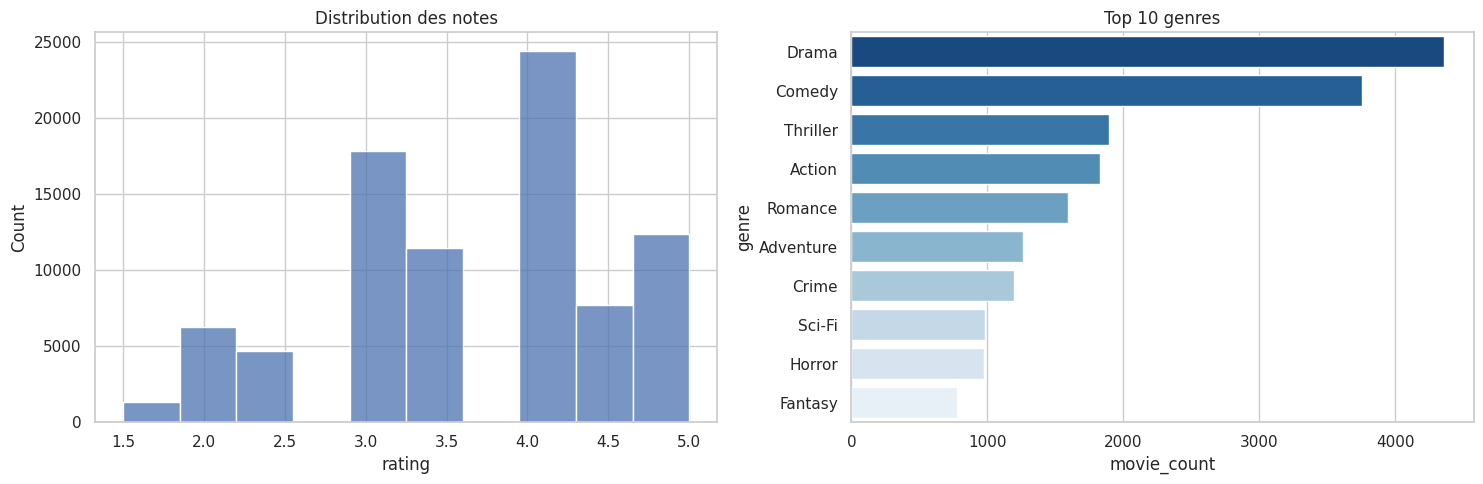

,genre,movie_count
0,Drama,4361
1,Comedy,3756
2,Thriller,1894
3,Action,1828
4,Romance,1596
5,Adventure,1263
6,Crime,1199
7,Sci-Fi,980
8,Horror,978
9,Fantasy,779


In [8]:
ratings_pdf = ratings_clean_df.select("rating").toPandas()
movies_pdf = movies_clean_df.select("movieId", "genres").toPandas()

genre_counts = (
    movies_pdf["genres"]
    .fillna("")
    .str.split("|")
    .explode()
    .loc[lambda series: series.str.strip() != ""]
    .value_counts()
    .head(10)
    .reset_index()
)
genre_counts.columns = ["genre", "movie_count"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(ratings_pdf["rating"], bins=10, ax=axes[0])
axes[0].set_title("Distribution des notes")
axes[0].set_xlabel("rating")

sns.barplot(data=genre_counts, x="movie_count", y="genre", ax=axes[1], palette="Blues_r")
axes[1].set_title("Top 10 genres")
axes[1].set_xlabel("movie_count")
axes[1].set_ylabel("genre")

plt.tight_layout()
plt.show()

display(genre_counts)


## 8) Pipeline complet

Cette cellule lance l'equivalent de `python scripts/run_pipeline.py`.
Si le run est trop long, on passe temporairement sur `RUN_PROFILE = "balanced"` ou `RUN_PROFILE = "fast"`.


In [9]:
print(f"Running profile: {RUN_PROFILE} ({profile['expected_runtime']})")

pipeline_result = run_pipeline(
    spark=spark,
    settings=settings,
    use_tags=USE_TAGS,
    save_recommendations_to_postgres=False,
)

metrics_df = (
    pd.DataFrame(
        [{"metric": key, "value": value} for key, value in pipeline_result.items()]
    )
    .sort_values("metric")
    .reset_index(drop=True)
)
display(metrics_df)

priority_metrics = [
    "rmse",
    "mae",
    "precision_at_10",
    "recall_at_10",
    "ndcg_at_10",
    "content_tag_weight",
    "val_candidate_recall",
    "test_candidate_recall",
    "ranking_als_val_candidate_recall",
    "ranker_val_ndcg_at_k",
    "ranking_als_alpha",
]
display(metrics_df[metrics_df["metric"].isin(priority_metrics)].reset_index(drop=True))


Running profile: full (90-150+ min)


,metric,value
0,active_movies,9742.0
1,active_users,590.0
2,als_max_iter,10.0
3,als_rank,64.0
4,als_reg_param,0.12
5,als_val_rmse,0.751969
6,avg_als_score,0.680722
7,avg_content_score,0.090171
8,avg_final_score,-0.109112
9,avg_recommendations_per_user,10.0


,metric,value
0,content_tag_weight,0.3
1,mae,0.605086
2,ndcg_at_10,0.068187
3,precision_at_10,0.038644
4,ranker_val_ndcg_at_k,0.359143
5,ranking_als_alpha,10.0
6,ranking_als_val_candidate_recall,0.646513
7,recall_at_10,0.073028
8,rmse,0.762045
9,test_candidate_recall,0.762819


## 9) Verification des artefacts generes

On relit les fichiers produits dans `data/processed`.


In [10]:
recommendations_path = PROCESSED_DIR / "recommendations"
metrics_path = PROCESSED_DIR / "metrics" / "metrics.json"
metrics_history_path = PROCESSED_DIR / "metrics" / "metrics_history.jsonl"
seen_interactions_path = PROCESSED_DIR / "seen_interactions"

artifact_df = pd.DataFrame(
    [
        {"artifact": "recommendations_path", "path": str(recommendations_path), "exists": recommendations_path.exists()},
        {"artifact": "metrics_path", "path": str(metrics_path), "exists": metrics_path.exists()},
        {"artifact": "metrics_history_path", "path": str(metrics_history_path), "exists": metrics_history_path.exists()},
        {"artifact": "seen_interactions_path", "path": str(seen_interactions_path), "exists": seen_interactions_path.exists()},
    ]
)
display(artifact_df)

with open(metrics_path, "r", encoding="utf-8") as handle:
    metrics_payload = json.load(handle)

metrics_file_df = (
    pd.DataFrame([{"metric": key, "value": value} for key, value in metrics_payload.items()])
    .sort_values("metric")
    .reset_index(drop=True)
)
display(metrics_file_df)

recs_df = pd.read_parquet(recommendations_path)
display(recs_df.head(20))

if metrics_history_path.exists():
    history_df = pd.read_json(metrics_history_path, lines=True)
    display(history_df.tail(10))


,artifact,path,exists
0,recommendations_path,/content/recommandation_film/data/processed/re...,True
1,metrics_path,/content/recommandation_film/data/processed/me...,True
2,metrics_history_path,/content/recommandation_film/data/processed/me...,True
3,seen_interactions_path,/content/recommandation_film/data/processed/se...,True


,metric,value
0,active_movies,9742.000000
1,active_users,590.000000
2,als_max_iter,10.000000
3,als_rank,64.000000
4,als_reg_param,0.120000
5,als_val_rmse,0.751969
6,avg_als_score,0.680722
7,avg_content_score,0.090171
8,avg_final_score,-0.109112
9,avg_recommendations_per_user,10.000000


,userId,movieId,title,genres,rank,als_score,explicit_als_score,content_score,content_genre_score,content_tag_score,...,content_candidate_score,tag_candidate_score,popular_candidate_score,recent_candidate_score,source_als_candidate,source_content_candidate,source_tag_candidate,source_popular_candidate,source_recent_candidate,explanation
0,12,339,While You Were Sleeping (1995),Comedy|Romance,1,0.528026,4.314992,0.227227,0.324610,0.000000,...,0.324610,0.0,1.371723,0.047248,1,1,0,1,1,"Matched your preferred genres: Comedy, Romance"
1,12,597,Pretty Woman (1990),Comedy|Romance,2,0.257620,4.407606,0.227227,0.324610,0.000000,...,0.324610,0.0,1.494747,0.049533,1,1,0,1,1,"Matched your preferred genres: Comedy, Romance"
2,12,4447,Legally Blonde (2001),Comedy|Romance,3,0.264126,4.180981,0.227227,0.324610,0.000000,...,0.324610,0.0,1.005889,1.633578,1,1,0,1,1,"Matched your preferred genres: Comedy, Romance"
3,12,2858,American Beauty (1999),Drama|Romance,4,0.445485,4.445841,0.219372,0.313388,0.000000,...,0.000000,0.0,2.106500,0.051266,1,0,0,1,1,"Matched your preferred genres: Drama, Romance"
4,12,2424,You've Got Mail (1998),Comedy|Romance,5,0.124281,4.208177,0.227227,0.324610,0.000000,...,0.324610,0.0,1.071268,0.095071,1,1,0,1,1,"Matched your preferred genres: Comedy, Romance"
5,12,802,Phenomenon (1996),Drama|Romance,6,0.556567,4.260299,0.219372,0.313388,0.000000,...,0.000000,0.0,1.052303,0.089597,1,0,0,1,1,"Matched your preferred genres: Drama, Romance"
6,12,708,"Truth About Cats & Dogs, The (1996)",Comedy|Romance,7,0.310914,3.988526,0.227227,0.324610,0.000000,...,0.324610,0.0,1.160493,0.000000,1,1,0,1,0,"Matched your preferred genres: Comedy, Romance"
7,12,39,Clueless (1995),Comedy|Romance,8,0.245836,4.272363,0.227227,0.324610,0.000000,...,0.324610,0.0,1.324598,0.108613,1,1,0,1,1,"Matched your preferred genres: Comedy, Romance"
8,12,60069,WALL·E (2008),Adventure|Animation|Children|Romance|Sci-Fi,9,0.473685,4.422422,0.054996,0.078565,0.000000,...,0.000000,0.0,0.000000,0.024490,1,0,0,0,1,"Matched your preferred genres: Adventure, Anim..."
9,12,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller,10,0.731133,4.591381,0.050611,0.072301,0.000000,...,0.000000,0.0,0.000000,0.415458,1,0,0,0,1,"Matched your preferred genres: Action, Crime, ..."


,generated_at_utc,rmse,mae,precision_at_10,recall_at_10,ndcg_at_10,content_tag_weight,candidate_pool_size,val_candidate_recall,test_candidate_recall,...,catalog_coverage_ratio,avg_recommendations_per_user,avg_final_score,p50_final_score,p90_final_score,avg_als_score,avg_content_score,genres_covered,popularity_median_interactions,long_tail_recommendation_share
0,2026-04-10T00:35:53.993196+00:00,0.762045,0.605086,0.038644,0.073028,0.068187,0.3,400,0.778238,0.762819,...,0.071033,10,-0.109112,-0.098147,0.451734,0.680722,0.090171,18,11,0.010508


## 10) Test API dans le notebook

Ici on recharge l'API locale sur les artefacts generes puis on interroge quelques endpoints.


In [11]:
from fastapi.testclient import TestClient

os.environ["RECOMMENDATIONS_PATH"] = str(recommendations_path)
os.environ["METRICS_PATH"] = str(metrics_path)
os.environ["SEEN_INTERACTIONS_PATH"] = str(seen_interactions_path)
os.environ["METRICS_HISTORY_PATH"] = str(metrics_history_path)

client = TestClient(APP)
client.post("/reload")

health_payload = client.get("/health").json()
summary_payload = client.get("/dashboard/summary").json()
genres_payload = client.get("/dashboard/genres", params={"limit": 10}).json()
movies_payload = client.get("/dashboard/movies", params={"limit": 10}).json()
distribution_payload = client.get("/dashboard/final-score-distribution", params={"bins": 10}).json()

sample_user_id = int(recs_df["userId"].iloc[0])
recommendation_payload = client.get("/recommend", params={"user_id": sample_user_id, "k": TOP_K}).json()

print(health_payload)
display(pd.DataFrame(summary_payload.items(), columns=["metric", "value"]))
display(pd.DataFrame(genres_payload["rows"]))
display(pd.DataFrame(movies_payload["rows"]))
display(pd.DataFrame(distribution_payload["rows"]))
display(pd.DataFrame(recommendation_payload["recommendations"]))


{'status': 'ok'}


,metric,value
0,rmse,0.762045
1,mae,0.605086
2,precision_at_10,0.038644
3,recall_at_10,0.073028
4,ndcg_at_10,0.068187
5,content_tag_weight,0.3
6,candidate_pool_size,400.0
7,val_candidate_recall,0.778238
8,test_candidate_recall,0.762819
9,ranker_val_precision_at_k,0.241284


,genre,recommendation_count,avg_final_score,share
0,Drama,2997,-0.127658,0.173508
1,Action,2090,-0.043845,0.120998
2,Thriller,1807,-0.065191,0.104614
3,Comedy,1768,-0.164703,0.102356
4,Adventure,1680,-0.062261,0.097262
5,Crime,1476,-0.120175,0.085451
6,Sci-Fi,1145,-0.066814,0.066288
7,Romance,979,-0.114076,0.056678
8,Fantasy,591,-0.134024,0.034215
9,Mystery,589,-0.085218,0.034099


,movieId,title,genres,exposure_count,avg_final_score,avg_rank
0,527,Schindler's List (1993),Drama|War,166,0.115909,3.873494
1,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114,0.063830,4.236842
2,2959,Fight Club (1999),Action|Crime|Drama|Thriller,85,0.104318,4.235294
3,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,83,0.142087,4.590361
4,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,82,0.109092,5.000000
5,1198,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,80,-0.047440,5.075000
6,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,78,0.007161,4.769231
7,318,"Shawshank Redemption, The (1994)",Crime|Drama,77,-0.024554,5.051948
8,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,75,0.024223,4.186667
9,2858,American Beauty (1999),Drama|Romance,75,-0.017654,5.040000


,bin_label,bin_start,bin_end,count
0,"(-3.4019999999999997, -2.874]",-3.402,-2.874,9
1,"(-2.874, -2.353]",-2.874,-2.353,4
2,"(-2.353, -1.831]",-2.353,-1.831,20
3,"(-1.831, -1.309]",-1.831,-1.309,84
4,"(-1.309, -0.788]",-1.309,-0.788,328
5,"(-0.788, -0.266]",-0.788,-0.266,1512
6,"(-0.266, 0.256]",-0.266,0.256,2681
7,"(0.256, 0.777]",0.256,0.777,1092
8,"(0.777, 1.299]",0.777,1.299,160
9,"(1.299, 1.821]",1.299,1.821,10


,movieId,title,genres,rank,als_score,content_score,final_score,explanation
0,339,While You Were Sleeping (1995),Comedy|Romance,1,0.528026,0.227227,1.262010,"Matched your preferred genres: Comedy, Romance"
1,597,Pretty Woman (1990),Comedy|Romance,2,0.257620,0.227227,1.225282,"Matched your preferred genres: Comedy, Romance"
2,4447,Legally Blonde (2001),Comedy|Romance,3,0.264126,0.227227,1.029741,"Matched your preferred genres: Comedy, Romance"
3,2858,American Beauty (1999),Drama|Romance,4,0.445485,0.219372,0.971236,"Matched your preferred genres: Drama, Romance"
4,2424,You've Got Mail (1998),Comedy|Romance,5,0.124281,0.227227,0.780066,"Matched your preferred genres: Comedy, Romance"
5,802,Phenomenon (1996),Drama|Romance,6,0.556567,0.219372,0.618742,"Matched your preferred genres: Drama, Romance"
6,708,"Truth About Cats & Dogs, The (1996)",Comedy|Romance,7,0.310914,0.227227,0.615406,"Matched your preferred genres: Comedy, Romance"
7,39,Clueless (1995),Comedy|Romance,8,0.245836,0.227227,0.602911,"Matched your preferred genres: Comedy, Romance"
8,60069,WALL·E (2008),Adventure|Animation|Children|Romance|Sci-Fi,9,0.473685,0.054996,0.527999,"Matched your preferred genres: Adventure, Anim..."
9,293,Léon: The Professional (a.k.a. The Professiona...,Action|Crime|Drama|Thriller,10,0.731133,0.050611,0.452434,"Matched your preferred genres: Action, Crime, ..."


## 11) Export zip des resultats

Cette cellule prepare un bundle facile a telecharger depuis Colab avec le notebook, le code, les dashboards et les artefacts.


In [12]:
import shutil

export_dir = PROJECT_ROOT / "recommandation_film_colab_export"
archive_base = PROJECT_ROOT / "recommandation_film_colab_export"

if export_dir.exists():
    shutil.rmtree(export_dir)
export_dir.mkdir(parents=True, exist_ok=True)

shutil.copy2(PROJECT_ROOT / "notebooks" / "eda_movielens.ipynb", export_dir / "eda_movielens.ipynb")
shutil.copy2(PROJECT_ROOT / "requirements.txt", export_dir / "requirements.txt")
shutil.copy2(PROJECT_ROOT / "README.MD", export_dir / "README.MD")
shutil.copytree(PROJECT_ROOT / "data" / "processed", export_dir / "data_processed")
shutil.copytree(PROJECT_ROOT / "dashboards", export_dir / "dashboards")
shutil.copytree(PROJECT_ROOT / "src", export_dir / "src")
shutil.copytree(PROJECT_ROOT / "scripts", export_dir / "scripts")

archive_path = shutil.make_archive(str(archive_base), "zip", export_dir)
print(f"Export ready: {archive_path}")

if IN_COLAB:
    from google.colab import files

    files.download(archive_path)


Export ready: /content/recommandation_film/recommandation_film_colab_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12) Nettoyage

Quand tu as fini, tu peux fermer proprement Spark avec la cellule suivante.


In [13]:
# spark.stop()
